#### Actividad 6.2

Ivanna Maldonado Cervantes


In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_rows", None)

In [3]:
#Carga desde un archivo .csv sin indice
data= pd.read_csv('listingsbudapest.csv') 
data = data.drop('calendar_updated', axis=1)
data = data.drop('neighbourhood_group_cleansed', axis=1)
data["price"] = data["price"].replace('[\$,]', '', regex=True)
data["price"] = data["price"].astype(float)
data.info()

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/var/folders/vv/zkrntk9d6sjc4rn30m21zp2w0000gp/T/ipykernel_31922/3263005286.py:5: SyntaxWarning: invalid escape sequence '\$'
  data["price"] = data["price"].replace('[\$,]', '', regex=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12391 entries, 0 to 12390
Data columns (total 77 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            12391 non-null  int64  
 1   listing_url                                   12391 non-null  object 
 2   scrape_id                                     12391 non-null  int64  
 3   last_scraped                                  12391 non-null  object 
 4   source                                        12391 non-null  object 
 5   name                                          12391 non-null  object 
 6   description                                   12086 non-null  object 
 7   neighborhood_overview                         6375 non-null   object 
 8   picture_url                                   12391 non-null  object 
 9   host_id                                       12391 non-null 

In [4]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

id                                                 0
listing_url                                        0
scrape_id                                          0
last_scraped                                       0
source                                             0
name                                               0
description                                      305
neighborhood_overview                           6016
picture_url                                        0
host_id                                            0
host_url                                           0
host_name                                          1
host_since                                         1
host_location                                   3551
host_about                                      5496
host_response_time                              1207
host_response_rate                              1207
host_acceptance_rate                             681
host_is_superhost                             

In [5]:
data.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms',
       'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_3

In [6]:
#Aplicar métodos (Desviación Estándar y Rango Intercuartílico) para eliminar Outliers, 
# comprobar con diagramas de caja por cada columna

In [7]:
#Reemplazamos valores nulos del dataframe con "bfill"
data1 =data.fillna(method="ffill") 
data1.head()

/var/folders/vv/zkrntk9d6sjc4rn30m21zp2w0000gp/T/ipykernel_31922/1210798527.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data1 =data.fillna(method="ffill")


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6020,https://www.airbnb.com/rooms/6020,20250925033058,2025-09-25,city scrape,"Perfect location in the center,clean,personal ...",Cozy 50 m2 apartment with Danube river sidevi...,"The area is loved by locals , close to all sig...",https://a0.muscache.com/pictures/miso/Hosting-...,2850,...,4.90,4.88,4.69,MA19013341,t,3,3,0,0,0.67
1,6022,https://www.airbnb.com/rooms/6022,20250925033058,2025-09-25,city scrape,"2 bedrooms , quiet-local-clean perfect location","Artists of Suite ( ArtSu ) , an exceptional...",Location : Perfect ! The Danube river only 20 ...,https://a0.muscache.com/pictures/2bb86bba-4ed1...,2850,...,4.96,4.98,4.83,MA19013341,f,3,3,0,0,0.31
2,15304,https://www.airbnb.com/rooms/15304,20250925033058,2025-09-25,city scrape,Astoria Station Private Triple Room by Budapes...,BUDAPESTING's Astoria Garden View Private Room...,Astoria square / station is the geographical c...,https://a0.muscache.com/pictures/miso/Hosting-...,60010,...,4.70,4.87,4.63,MA19003534,t,34,15,19,0,1.42
3,15306,https://www.airbnb.com/rooms/15306,20250925033058,2025-09-25,city scrape,Synagogue Residence Private Room by Budapesting,BUDAPESTING's Astoria Residence Private Room h...,Astoria square / station is the geographical c...,https://a0.muscache.com/pictures/miso/Hosting-...,60010,...,4.68,4.87,4.68,MA19003534,t,34,15,19,0,1.45
4,15307,https://www.airbnb.com/rooms/15307,20250925033058,2025-09-25,city scrape,Jewish District Private Triple Room by Budapes...,BUDAPESTING's Astoria Residence Triple Room is...,Astoria square / station is the geographical c...,https://a0.muscache.com/pictures/miso/Hosting-...,60010,...,4.66,4.91,4.67,MA19003534,t,34,15,19,0,1.44


In [8]:
#Creo 2 dataframe para poder procesar los outliers
cualitativos = [
    'id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
    'description', 'neighborhood_overview', 'picture_url', 'host_id',
    'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
    'host_response_time', 'host_response_rate', 'host_acceptance_rate',
    'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
    'host_neighbourhood', 'host_verifications', 'host_has_profile_pic',
    'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed',
    'property_type', 'room_type', 'bathrooms_text', 'amenities', 'has_availability',
    'calendar_last_scraped', 'first_review', 'last_review', 'license',
    'instant_bookable'
]
cuantitativos= [
    'latitude', 'longitude', 'host_listings_count', 'host_total_listings_count',
    'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
    'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
    'maximum_minimum_nights', 'minimum_maximum_nights',
    'maximum_maximum_nights', 'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm', 'availability_30', 'availability_60',
    'availability_90', 'availability_365', 'number_of_reviews',
    'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy',
    'number_of_reviews_ly', 'estimated_occupancy_l365d',
    'estimated_revenue_l365d', 'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
    'reviews_per_month'
]

df_cuali = data1[cualitativos]
df_cuanti = data1[cuantitativos]

<Figure size 1500x800 with 0 Axes>

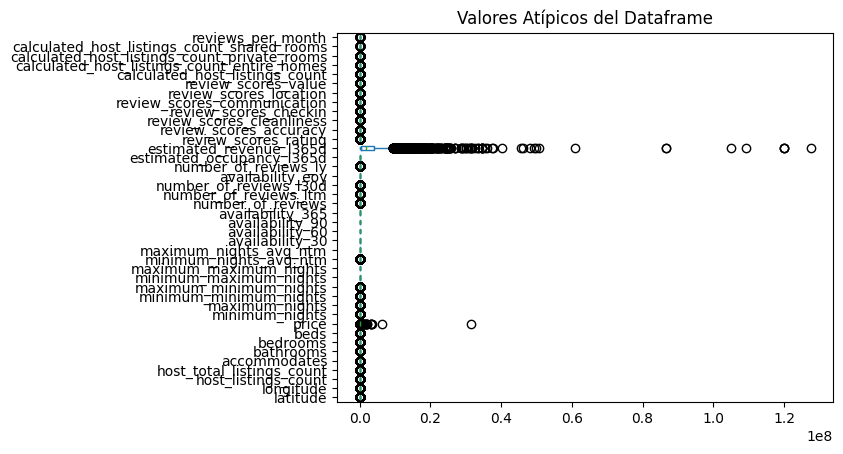

In [9]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
df_cuanti.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

In [10]:
#Método aplicando desviación estandar. Encuentro los valores extremos
#desv est detecta menos datos outliers que interquartilicos.
y=df_cuanti
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido latitude                                        4.754338e+01
longitude                                       1.912001e+01
host_listings_count                             3.633184e+02
host_total_listings_count                       4.870396e+02
accommodates                                    1.101438e+01
bathrooms                                       3.109721e+00
bedrooms                                        4.492924e+00
beds                                            7.982415e+00
price                                           9.412693e+05
minimum_nights                                  5.647203e+01
maximum_nights                                  1.489369e+03
minimum_minimum_nights                          5.016721e+01
maximum_minimum_nights                          7.562548e+01
minimum_maximum_nights                          1.932633e+03
maximum_maximum_nights                          1.957674e+03
minimum_nights_avg_ntm                          6.500924e+0

In [11]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data2= df_cuanti[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data2.head()

,latitude,longitude,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,47.51425,19.04829,3.0,4.0,3.0,1.0,2.0,2.0,24620.0,2.0,...,4.87,4.84,4.90,4.88,4.69,3.0,3.0,0.0,0.0,0.67
1,47.51481,19.04871,3.0,4.0,3.0,1.0,2.0,3.0,23881.0,2.0,...,5.00,4.93,4.96,4.98,4.83,3.0,3.0,0.0,0.0,0.31
2,47.49530,19.06096,34.0,49.0,3.0,2.0,1.0,2.0,98397.0,NaN,...,4.46,4.73,4.70,4.87,4.63,34.0,15.0,19.0,0.0,1.42
3,47.49530,19.06096,34.0,49.0,3.0,2.0,1.0,2.0,23007.0,NaN,...,4.55,4.65,4.68,4.87,4.68,34.0,15.0,19.0,0.0,1.45
4,47.49530,19.06096,34.0,49.0,3.0,2.0,1.0,2.0,23427.0,NaN,...,4.44,4.69,4.66,4.91,4.67,34.0,15.0,19.0,0.0,1.44


In [12]:
#Corroboramos valores nulos del dataframe 4
valores_nulos=data2.isnull().sum()
valores_nulos

latitude                                        327
longitude                                       224
host_listings_count                             404
host_total_listings_count                       404
accommodates                                    237
bathrooms                                       163
bedrooms                                        201
beds                                            206
price                                            14
minimum_nights                                  102
maximum_nights                                    1
minimum_minimum_nights                           88
maximum_minimum_nights                          160
minimum_maximum_nights                            0
maximum_maximum_nights                            0
minimum_nights_avg_ntm                          111
maximum_nights_avg_ntm                            0
availability_30                                   0
availability_60                                   0
availability

In [13]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data_clean=data2.copy()
data_clean=data_clean.fillna(round(data2.mean(),1))
data_clean.head()

,latitude,longitude,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,47.51425,19.04829,3.0,4.0,3.0,1.0,2.0,2.0,24620.0,2.0,...,4.87,4.84,4.90,4.88,4.69,3.0,3.0,0.0,0.0,0.67
1,47.51481,19.04871,3.0,4.0,3.0,1.0,2.0,3.0,23881.0,2.0,...,5.00,4.93,4.96,4.98,4.83,3.0,3.0,0.0,0.0,0.31
2,47.49530,19.06096,34.0,49.0,3.0,2.0,1.0,2.0,98397.0,2.3,...,4.46,4.73,4.70,4.87,4.63,34.0,15.0,19.0,0.0,1.42
3,47.49530,19.06096,34.0,49.0,3.0,2.0,1.0,2.0,23007.0,2.3,...,4.55,4.65,4.68,4.87,4.68,34.0,15.0,19.0,0.0,1.45
4,47.49530,19.06096,34.0,49.0,3.0,2.0,1.0,2.0,23427.0,2.3,...,4.44,4.69,4.66,4.91,4.67,34.0,15.0,19.0,0.0,1.44


In [14]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data_clean.isnull().sum()
valores_nulos

latitude                                        0
longitude                                       0
host_listings_count                             0
host_total_listings_count                       0
accommodates                                    0
bathrooms                                       0
bedrooms                                        0
beds                                            0
price                                           0
minimum_nights                                  0
maximum_nights                                  0
minimum_minimum_nights                          0
maximum_minimum_nights                          0
minimum_maximum_nights                          0
maximum_maximum_nights                          0
minimum_nights_avg_ntm                          0
maximum_nights_avg_ntm                          0
availability_30                                 0
availability_60                                 0
availability_90                                 0


In [15]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=df_cuanti

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido latitude                                        4.752199e+01
longitude                                       1.908827e+01
host_listings_count                             8.700000e+01
host_total_listings_count                       1.170000e+02
accommodates                                    9.500000e+00
bathrooms                                       2.250000e+00
bedrooms                                        3.500000e+00
beds                                            6.000000e+00
price                                           5.756475e+04
minimum_nights                                  3.500000e+00
maximum_nights                                  7.775000e+02
minimum_minimum_nights                          3.500000e+00
maximum_minimum_nights                          7.000000e+00
minimum_maximum_nights                          2.662500e+03
maximum_maximum_nights                          2.265000e+03
minimum_nights_avg_ntm                          4.250000e+0

In [16]:
#Obtenemos datos limpios del Dataframe
data2_iqr= df_cuanti[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data2_iqr.head()

,latitude,longitude,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,47.51425,19.04829,3.0,4.0,3.0,1.0,2.0,2.0,24620.0,2.0,...,4.87,4.84,4.90,4.88,4.69,3.0,3.0,0.0,0.0,0.67
1,47.51481,19.04871,3.0,4.0,3.0,1.0,2.0,3.0,23881.0,2.0,...,5.00,4.93,4.96,4.98,4.83,3.0,3.0,0.0,0.0,0.31
2,47.49530,19.06096,34.0,49.0,3.0,2.0,1.0,2.0,NaN,NaN,...,4.46,4.73,4.70,4.87,4.63,34.0,15.0,NaN,0.0,1.42
3,47.49530,19.06096,34.0,49.0,3.0,2.0,1.0,2.0,23007.0,NaN,...,4.55,4.65,4.68,4.87,4.68,34.0,15.0,NaN,0.0,1.45
4,47.49530,19.06096,34.0,49.0,3.0,2.0,1.0,2.0,23427.0,NaN,...,4.44,4.69,4.66,4.91,4.67,34.0,15.0,NaN,0.0,1.44


In [17]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data2_iqr.isnull().sum()
valores_nulos

latitude                                         859
longitude                                       1189
host_listings_count                             2130
host_total_listings_count                       1919
accommodates                                     449
bathrooms                                        774
bedrooms                                         477
beds                                             305
price                                           1225
minimum_nights                                   689
maximum_nights                                  2111
minimum_minimum_nights                           489
maximum_minimum_nights                           610
minimum_maximum_nights                             0
maximum_maximum_nights                             0
minimum_nights_avg_ntm                           692
maximum_nights_avg_ntm                             0
availability_30                                    0
availability_60                               

In [18]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data3_iqr=data2_iqr.copy()
data3_iqr=data3_iqr.fillna(round(data2_iqr.median(),1))
data3_iqr.head()

,latitude,longitude,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,47.51425,19.04829,3.0,4.0,3.0,1.0,2.0,2.0,24620.0,2.0,...,4.87,4.84,4.90,4.88,4.69,3.0,3.0,0.0,0.0,0.67
1,47.51481,19.04871,3.0,4.0,3.0,1.0,2.0,3.0,23881.0,2.0,...,5.00,4.93,4.96,4.98,4.83,3.0,3.0,0.0,0.0,0.31
2,47.49530,19.06096,34.0,49.0,3.0,2.0,1.0,2.0,20523.0,2.0,...,4.46,4.73,4.70,4.87,4.63,34.0,15.0,0.0,0.0,1.42
3,47.49530,19.06096,34.0,49.0,3.0,2.0,1.0,2.0,23007.0,2.0,...,4.55,4.65,4.68,4.87,4.68,34.0,15.0,0.0,0.0,1.45
4,47.49530,19.06096,34.0,49.0,3.0,2.0,1.0,2.0,23427.0,2.0,...,4.44,4.69,4.66,4.91,4.67,34.0,15.0,0.0,0.0,1.44


In [19]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([df_cuali, data3_iqr], axis=1)
Datos_limpios.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6020,https://www.airbnb.com/rooms/6020,20250925033058,2025-09-25,city scrape,"Perfect location in the center,clean,personal ...",Cozy 50 m2 apartment with Danube river sidevi...,"The area is loved by locals , close to all sig...",https://a0.muscache.com/pictures/miso/Hosting-...,2850,...,4.87,4.84,4.90,4.88,4.69,3.0,3.0,0.0,0.0,0.67
1,6022,https://www.airbnb.com/rooms/6022,20250925033058,2025-09-25,city scrape,"2 bedrooms , quiet-local-clean perfect location","Artists of Suite ( ArtSu ) , an exceptional...",Location : Perfect ! The Danube river only 20 ...,https://a0.muscache.com/pictures/2bb86bba-4ed1...,2850,...,5.00,4.93,4.96,4.98,4.83,3.0,3.0,0.0,0.0,0.31
2,15304,https://www.airbnb.com/rooms/15304,20250925033058,2025-09-25,city scrape,Astoria Station Private Triple Room by Budapes...,BUDAPESTING's Astoria Garden View Private Room...,Astoria square / station is the geographical c...,https://a0.muscache.com/pictures/miso/Hosting-...,60010,...,4.46,4.73,4.70,4.87,4.63,34.0,15.0,0.0,0.0,1.42
3,15306,https://www.airbnb.com/rooms/15306,20250925033058,2025-09-25,city scrape,Synagogue Residence Private Room by Budapesting,BUDAPESTING's Astoria Residence Private Room h...,Astoria square / station is the geographical c...,https://a0.muscache.com/pictures/miso/Hosting-...,60010,...,4.55,4.65,4.68,4.87,4.68,34.0,15.0,0.0,0.0,1.45
4,15307,https://www.airbnb.com/rooms/15307,20250925033058,2025-09-25,city scrape,Jewish District Private Triple Room by Budapes...,BUDAPESTING's Astoria Residence Triple Room is...,Astoria square / station is the geographical c...,https://a0.muscache.com/pictures/miso/Hosting-...,60010,...,4.44,4.69,4.66,4.91,4.67,34.0,15.0,0.0,0.0,1.44


In [20]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

id                                              0
listing_url                                     0
scrape_id                                       0
last_scraped                                    0
source                                          0
name                                            0
description                                     0
neighborhood_overview                           0
picture_url                                     0
host_id                                         0
host_url                                        0
host_name                                       0
host_since                                      0
host_location                                   0
host_about                                      0
host_response_time                              0
host_response_rate                              0
host_acceptance_rate                            0
host_is_superhost                               0
host_thumbnail_url                              0


In [21]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Budapest_Limpios.csv")